Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Load data

In [2]:
file_path = "Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

Quick peek

In [3]:
print(df.head())
print(df.info())
print(df.isna().sum())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

2. Handle missing vvalues in Churn Reason

In [4]:
df['Churn Reason'] = df['Churn Reason'].fillna('Retained')

print("Missing values after handling:\n", df.isna().sum())

Missing values after handling:
 CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64


Remove duplicates

In [5]:
print("Shape before duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after duplicates:", df.shape)

Shape before duplicates: (7043, 33)
Shape after duplicates: (7043, 33)


Convert categorical → numerical

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

# Example: target encoding for 'Churn' if present
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')

# Binary yes/no columns → 0/1
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = df[col].map(binary_map).fillna(df[col])



print("Data types after encoding:\n", df.dtypes.head())

print("Data types after encoding:\n", df.head())

Data types after encoding:
 CustomerID      str
Count         int64
Country         str
State           str
City            str
dtype: object
Data types after encoding:
    CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783       1  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420       0  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953       0  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709       0  ...

C:\Users\parim\AppData\Local\Temp\ipykernel_37836\2992223598.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


5. Feature engineering

In [8]:
# 5.1 Create tenure groups

bins = [0, 12, 24, 48, float('inf')]
labels = ["0–1 year", "1–2 years", "2–4 years", "4+ years"]

df["tenure_group"] = pd.cut(df["Tenure Months"], bins=bins, labels=labels, right=True)
print("Tenure groups created:\n", df["tenure_group"].value_counts())

# 5.2 Create Average usage per month
if "Total Charges" in df.columns and "Tenure Months" in df.columns:
    df["avg_monthly_charges"] = df["Total Charges"] / df["Tenure Months"].replace(0, np.nan)
    print("Average monthly charges created:\n", df["avg_monthly_charges"].head())

# 5.3 Create interaction feature: Contract type + Payment method
if "Contract" in df.columns and "Payment Method" in df.columns:
    df["contract_payment_interaction"] = df["Contract"].astype(str) + "_" + df["Payment Method"].astype(str)
    print("Interaction feature created:\n", df["contract_payment_interaction"].value_counts().head())

# 5.4 Create a feature for customers with multiple services
service_cols = [col for col in df.columns if "Service" in col]
if service_cols:
    df["num_services"] = df[service_cols].apply(lambda x: x.notna().sum(), axis=1)
    print("Number of services feature created:\n", df["num_services"].value_counts().head())

# 5.5 Create a feature for payment risk based on payment method and contract
if "Payment Method" in df.columns and "Contract" in df.columns:
    risk_map = {
        "Electronic check": "high",
        "Mailed check": "medium",
        "Bank transfer (automatic)": "low",
        "Credit card (automatic)": "low"
    }
    df["payment_risk"] = df["Payment Method"].map(risk_map).fillna(0)
    print("Payment risk feature created:\n", df["payment_risk"].value_counts().head())

Tenure groups created:
 tenure_group
4+ years     2239
0–1 year     2175
2–4 years    1594
1–2 years    1024
Name: count, dtype: int64
Average monthly charges created:
 0        54.075
1        75.825
2      102.5625
3      108.7875
4    102.781633
Name: avg_monthly_charges, dtype: object
Interaction feature created:
 contract_payment_interaction
Month-to-month_Electronic check             1850
Month-to-month_Mailed check                  893
Month-to-month_Bank transfer (automatic)     589
Two year_Credit card (automatic)             581
Two year_Bank transfer (automatic)           564
Name: count, dtype: int64
Number of services feature created:
 num_services
2    7043
Name: count, dtype: int64
Payment risk feature created:
 payment_risk
low       3066
high      2365
medium    1612
Name: count, dtype: int64


6. Explorotory Data Analysis (EDA)

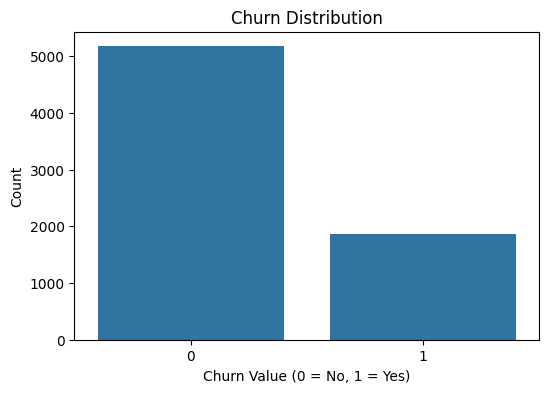

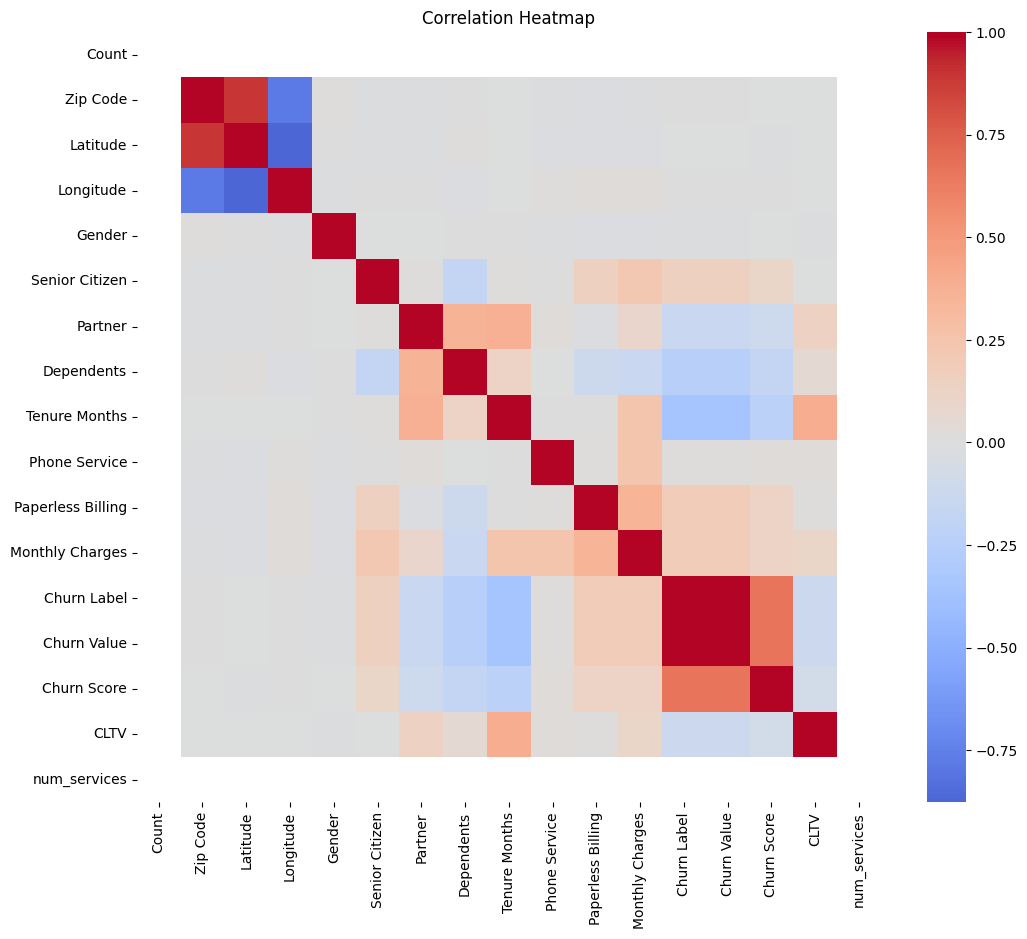

Top correlations with Churn:
 Churn Label          1.000000
Churn Score          0.664897
Tenure Months        0.352229
Dependents           0.248542
Monthly Charges      0.193356
Paperless Billing    0.191825
Senior Citizen       0.150889
Partner              0.150448
CLTV                 0.127463
Phone Service        0.011942
Gender               0.008612
Longitude            0.004594
Latitude             0.003384
Zip Code             0.003346
Count                     NaN
num_services              NaN
Name: Churn Value, dtype: float64


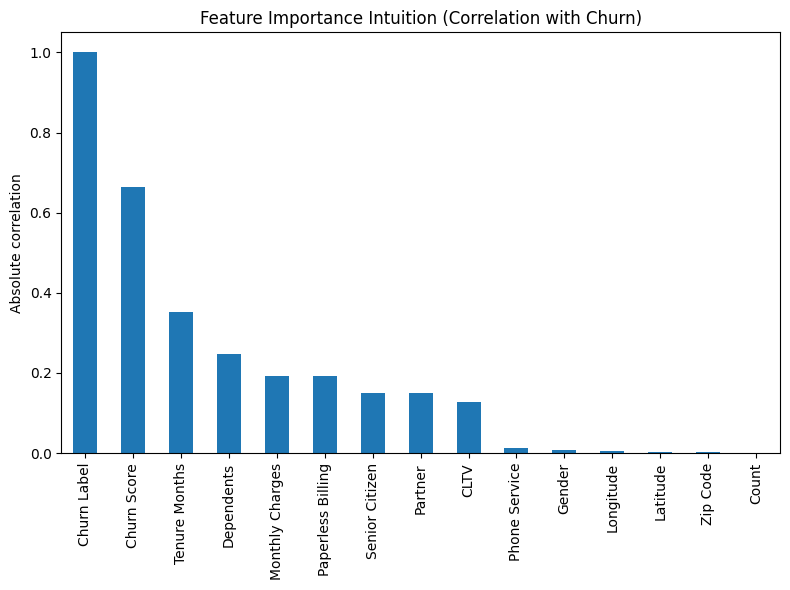

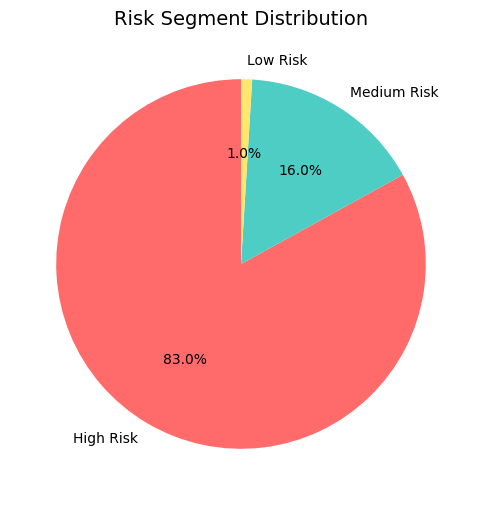

In [29]:
# 6.1 Churn distribution
if "Churn Value" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x="Churn Value", data=df)
    plt.title("Churn Distribution")
    plt.xlabel("Churn Value (0 = No, 1 = Yes)")
    plt.ylabel("Count")
    plt.show()

# 6.2 Correlation heatmap (numeric only)
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# 6.3 Feature importance intuition (via simple model-free correlation with target)
# Take absolute correlation with churn and sort
churn_corr = corr['Churn Value'].drop('Churn Value').abs().sort_values(ascending=False)
print("Top correlations with Churn:\n", churn_corr.head(20))

plt.figure(figsize=(8, 6))
churn_corr.head(15).plot(kind='bar')
plt.title("Feature Importance Intuition (Correlation with Churn)")
plt.ylabel("Absolute correlation")
plt.tight_layout()
plt.show()

# 6.3 Customer segmentation (high risk vs low risk)
import numpy as np

# High-risk conditions
high_risk_conditions = (
    (df["Tenure Months"] < 12) |
    (df["Monthly Charges"] > 80) |
    (df["Contract"] == "Month-to-month") |
    (df["Payment Method"] == "Electronic check") |
    (df["Online Security"] == "No") |
    (df["Tech Support"] == "No")
)

# Low-risk conditions
low_risk_conditions = (
    (df["Tenure Months"] > 24) &
    (df["Monthly Charges"] < 60) &
    (df["Contract"].isin(["One year", "Two year"])) &
    (df["Payment Method"].isin(["Bank transfer (automatic)", "Credit card (automatic)"])) &
    (df["Online Security"] == "Yes") &
    (df["Tech Support"] == "Yes")
)

# Create segment column
df["risk_segment"] = np.where(high_risk_conditions, "High Risk",
                       np.where(low_risk_conditions, "Low Risk", "Medium Risk"))

plt.figure(figsize=(6,6))
df["risk_segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff6b6b", "#4ecdc4", "#ffe66d"]
)

plt.title("Risk Segment Distribution", fontsize=14)
plt.ylabel("")
plt.show()



In [30]:
df.to_excel('processed_telco_churn.xlsx', index=False)
print("DataFrame saved to 'processed_telco_churn.xlsx'")

DataFrame saved to 'processed_telco_churn.xlsx'
